In [2]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('../DadosLimpos_Venda_Sorvete.csv')
df

,preco,temperatura_c,umidade_pct,dia_semana,demanda
0,8.0,10.0,85.00,1,170
1,9.3,11.8,81.00,2,187
2,10.6,13.6,77.00,3,204
3,11.9,15.4,73.00,4,220
4,13.2,17.2,59.19,5,237
...,...,...,...,...,...
115,15.6,24.4,51.60,4,268
116,16.9,26.2,47.60,5,284
117,18.2,28.0,43.60,6,301
118,19.5,29.8,39.60,7,318


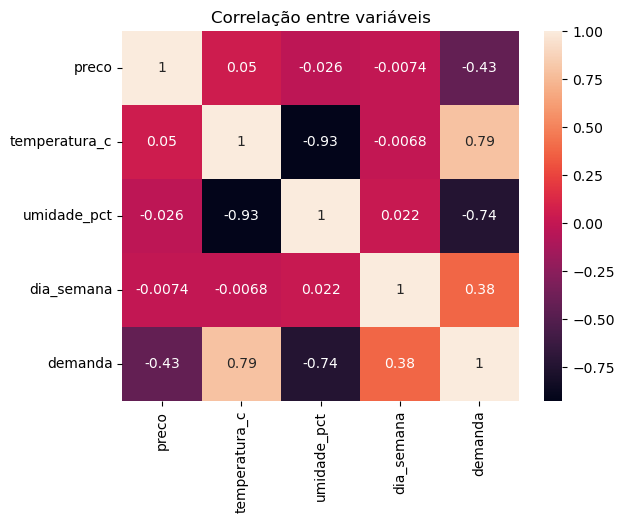

In [31]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title('Correlação entre variáveis')
plt.show()

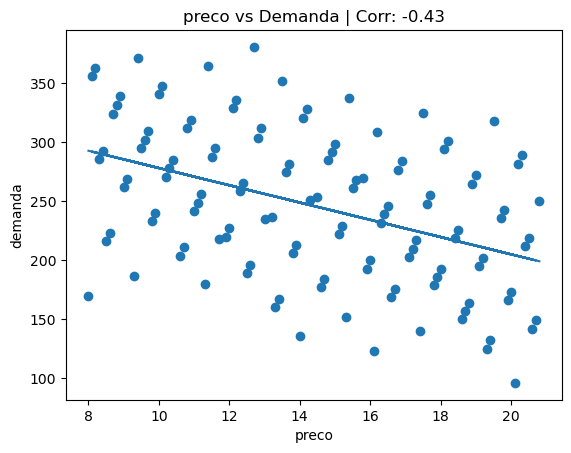

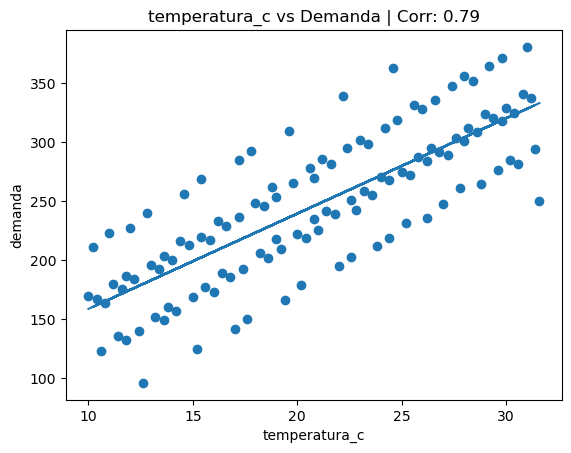

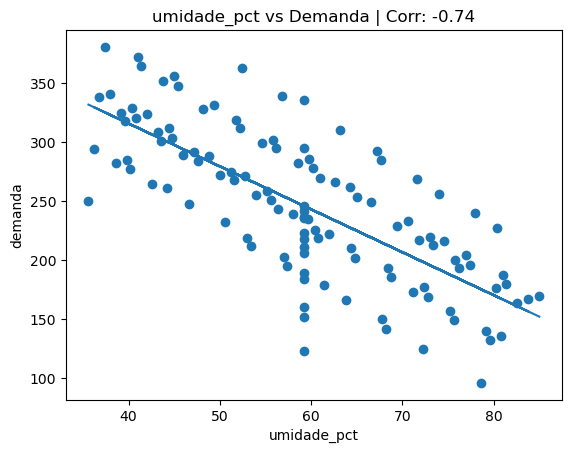

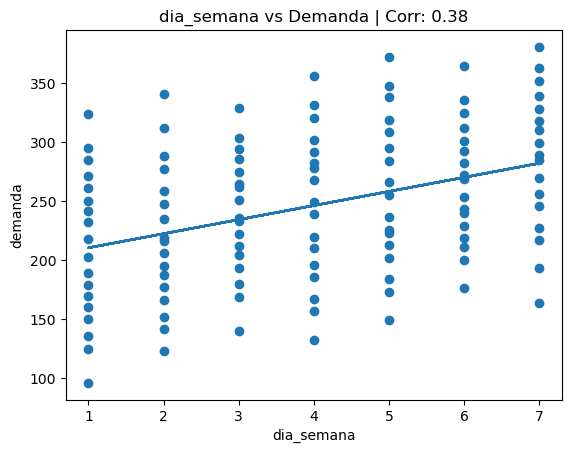

In [32]:
colunas_numericas = df.select_dtypes(include=[np.number]).columns

# Remover a própria demanda da lista
colunas_numericas = colunas_numericas.drop('demanda')

# Loop para plotar cada variável vs demanda
for col in colunas_numericas:
    
    plt.figure()
    
    # Scatter plot
    plt.scatter(df[col], df['demanda'])
    
    # Linha de tendência (regressão linear)
    z = np.polyfit(df[col], df['demanda'], 1)
    p = np.poly1d(z)
    plt.plot(df[col], p(df[col]))
    
    # Correlação
    corr = df[col].corr(df['demanda'])
    
    plt.title(f'{col} vs Demanda | Corr: {corr:.2f}')
    plt.xlabel(col)
    plt.ylabel('demanda')
    
    plt.show()

## Treinando Modelo Linear 

In [47]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =========================
# 1. Definir X e y
# =========================
X = df.drop(columns=['demanda'])
y = df['demanda']

# =========================
# 2. Train/Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, random_state=42
)

# =========================
# 3. Treinar modelo
# =========================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================
# 4. Previsão
# =========================
y_pred = model.predict(X_test)

# =========================
# 5. Métricas
# =========================
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))


print("📊 RESULTADOS TESTE")
print(f"R2: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

# =========================
# 6. Cross Validation
# =========================
cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2')
cv_mae = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
cv_mse = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')

print("\n📊 CROSS VALIDATION (5 folds)")
print(f"R2 médio: {cv_r2.mean():.4f}")
print(f"MAE médio: {-cv_mae.mean():.4f}")
print(f"MSE médio: {-cv_mse.mean():.4f}")

📊 RESULTADOS TESTE
R2: 0.9998
MAE: 0.7036
MSE: 0.6426
RMSE: 0.8016

📊 CROSS VALIDATION (5 folds)
R2 médio: 0.9998
MAE médio: 0.7617
MSE médio: 0.7869


# Treinando Modelo Ensemble Gradiente Descend

In [34]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# =========================
# Modelo XGBoost
# =========================
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

# Treinar
xgb_model.fit(X_train, y_train)

# Previsão
y_pred_xgb = xgb_model.predict(X_test)

# =========================
# Métricas
# =========================
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print("📊 RESULTADOS XGBOOST")
print(f"R2: {r2_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")
print(f"MSE: {mse_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")

📊 RESULTADOS XGBOOST
R2: 0.9554
MAE: 11.6015
MSE: 184.2856
RMSE: 13.5752


In [35]:
df['demanda'].mean()

np.float64(246.06666666666666)

In [36]:
from sklearn.model_selection import cross_val_score

cv_r2_xgb = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')
cv_rmse_xgb = cross_val_score(
    xgb_model, X, y, cv=5, scoring='neg_root_mean_squared_error'
)

print("\n📊 CROSS VALIDATION XGBOOST")
print(f"R2 médio: {cv_r2_xgb.mean():.4f}")
print(f"RMSE médio: {-cv_rmse_xgb.mean():.4f}")


📊 CROSS VALIDATION XGBOOST
R2 médio: 0.9428
RMSE médio: 14.4883


In [51]:
for col in df.columns:
    print(col)
    print(df[col].std())
 

preco
3.765611760759879
temperatura_c
6.266356747804604
umidade_pct
12.94895945658968
dia_semana
2.018662923818635
demanda
63.727061562182044
